# Monte Carlo Uncertainty Analysis (Hardened API)

This notebook demonstrates Monte Carlo uncertainty quantification for HEC-RAS hydraulic
models using the **hardened** `RasMonteCarlo` public API. The workflow generates parameter
samples from user-defined distributions, runs an ensemble of simulations via `RasPermutation`,
surfaces ensemble health, checks convergence, and computes percentile/prediction statistics
from the resulting HDF outputs.

## What You'll Learn

- Generate parameter samples with **Latin hypercube** (LHS) and **truncated-normal** methods
- Build an `apply_fn` with the shipped factory `RasMonteCarlo.make_mannings_apply_fn()` (no inline reimplementation)
- Run an ensemble and read its **status histogram** (`completed` / `completed_with_errors` / `failed`)
- Check Monte Carlo **convergence** with `RasMonteCarlo.convergence()` before trusting the statistics
- Compute full-domain percentiles with `exceedance_probabilities()` (with the default 95% valid-fraction guard)
- Compute a labelled **prediction (percentile) interval** with `prediction_intervals()`
- Compute point-level WSE risk with `risk_at_points()` and read its `status_accounting` attrs

## How 2D Land-Cover Roughness Is Perturbed (Critical)

For a **2D land-cover model** the roughness Monte Carlo perturbs the **plain-text `.g##`
`LCMann Table` base overrides** via `RasMonteCarlo.make_mannings_apply_fn(path="plaintext")`.
For those perturbations to actually reach the solver, `run_ensemble()` MUST be called with:

- `clone_geom=True` -- gives every sample its **own geometry**, so each sample edits its own
  `.g##` `LCMann Table` instead of all samples sharing one geometry.
- `clear_geompre=True` -- **regenerates the cached per-cell** `Cells Center Manning's n` from
  the perturbed `LCMann` table; without it HEC-RAS reuses the stale preprocessed `n` and the
  ensemble is hydraulically inert (zero WSE spread).

`force_geompre` is not needed in this cloned-geometry workflow: `clone_geom=True` refreshes
each `.g##` mtime, so the smart skip cannot hide the edit, and `clear_geompre=True` clears
cached tables in place while preserving the sidecar association. Use `force_geompre=True`
for in-place sidecar edits whose unchanged `.g##` mtime would otherwise look current.

## Sample Sizes

- **Example 1 (breach + inflow)**: **N = 100** — production-scale ensemble distributed across
  remote workers. This is large enough for defensible P10/P50/P90 estimation on the primary
  uncertainty drivers. The convergence diagnostic below reports whether the statistic stabilizes.
- **Example 2 (roughness contrast)**: **N = 30** — demonstration-scale ensemble showing that
  roughness is a secondary/tertiary driver for this dam-breach scenario. Kept small since the
  point is the *contrast* against Example 1, not standalone percentile reliability.

The repository research (`feature_dev_notes/Monte_Carlo_Uncertainty/research_findings.md` §9)
calls for ~500–1000 LHS samples for robust tail percentiles (P01/P99). N=100 is adequate for
P10/P90 but not for extreme tails.

## Two Examples

| Example | Sampling method | Parameters varied | Output analysis |
|---------|----------------|-------------------|-----------------|
| 1 | Latin hypercube (N=100) | Breach formation (width, time, slopes) + inflow multiplier | Full-domain percentiles + convergence + prediction interval + WSE-sensitivity guard |
| 2 | Truncated normal (N=30) | Manning's n (correlated multiplier, all wetted classes) | Point-level WSE risk statistics |

## Prerequisites

- HEC-RAS 6.x installed and resolvable by ras-commander
- `ras-commander` with the hardened `RasMonteCarlo` (this branch / ≥ the montecarlo-hardened release)
- **Expected runtime**: Example 1 uses remote workers (~8-10 hours with full fleet); Example 2 runs locally (~2-3 hours)
- Disk space: cloned batch folders are created under the project; reuse logic skips completed runs

In [1]:
# !pip install ras-commander --quiet

### Dev Mode — Local Source Install

Uncomment the block in the next cell to load `ras-commander` from a local clone instead of the
installed package. Leave it commented when running from the published package. Never leave both
the pip-install cell and the dev-mode block active at the same time.

In [2]:
# Dev-mode toggle: uncomment to use a local ras-commander clone
# import sys, importlib
# sys.path.insert(0, r"G:/GH/ras-commander")
# import ras_commander
# importlib.reload(ras_commander)

In [3]:
from pathlib import Path
import sys

# Flexible imports for development vs installed package
try:
    from ras_commander import (
        init_ras_project, ras, RasExamples, RasPlan,
        RasMonteCarlo, RasPermutation,
    )
    from ras_commander.geom import GeomLandCover
    from ras_commander.hdf import HdfMesh
except ImportError:
    current_file = Path.cwd()
    parent_directory = current_file.parent
    sys.path.append(str(parent_directory))
    from ras_commander import (
        init_ras_project, ras, RasExamples, RasPlan,
        RasMonteCarlo, RasPermutation,
    )
    from ras_commander.geom import GeomLandCover
    from ras_commander.hdf import HdfMesh

import re
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("default")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

# ── Configuration ─────────────────────────────────────────────────────
PROJECT_NAME   = "BaldEagleCrkMulti2D"   # 2D unsteady example project
RAS_VERSION    = "6.6"                    # installed HEC-RAS version
TEMPLATE_PLAN  = "01"                     # plan used as the MC template
N_SAMPLES_EX1  = 100                      # Ex1 ensemble size (production scale for breach+inflow)
N_SAMPLES_EX2  = 30                       # Ex2 ensemble size (demo scale — roughness contrast)
SEED           = 42                       # reproducible sampling
MAX_WORKERS    = 2                        # parallel HEC-RAS processes (2x2=4 cores, coexist-safe)
NUM_CORES      = 2                        # cores per HEC-RAS process
TIMEOUT_SEC    = 86400                    # 24 h hard cap -- covers slow geometry-preprocessing plans

# ── Breach / inflow configuration (for Example 1) ─────────────────────
# Plan 01 has three user-defined breaches: Dam (primary), Upper Levee, Lock Haven reach.
# Breach Geom (Dam) = 5700, 200, 595, 0.5, 0.5, True, 0.5, 630, ..., 2.6
#   initial_width   (index 1): 200 ft
#   final_bottom_elev (index 2): 595 ft
#   left/right slope  (idx 3/4): 0.5 H:V
#   formation_time  (index 9): 2.6 hr
# Inflow BC: "Upstream Q" lateral inflow into Reservoir Pool (unsteady file u01).
DAM_STRUCTURE          = "Dam"         # primary breach structure name in plan file
INFLOW_BC              = "Upstream Q"  # bc_line_name in ras.boundaries_df

BREACH_INIT_WIDTH_BASE = 200.0         # ft  (index 1 in Breach Geom)
BREACH_FORM_TIME_BASE  =   2.6         # hr  (index 9 in Breach Geom; library _BREACH_GEOM_INDEX)
BREACH_SLOPE_BASE      =   0.5         # H:V side slopes

print(f"N_SAMPLES_EX1 = {N_SAMPLES_EX1}, N_SAMPLES_EX2 = {N_SAMPLES_EX2}")
print(f"DAM_STRUCTURE={DAM_STRUCTURE!r}  INFLOW_BC={INFLOW_BC!r}")

2026-06-15 13:55:48 - numexpr.utils - INFO - NumExpr defaulting to 8 threads.


N_SAMPLES_EX1 = 100, N_SAMPLES_EX2 = 30
DAM_STRUCTURE='Dam'  INFLOW_BC='Upstream Q'


## Step 1 — Extract Project and Inspect Manning's n Table

We use `BaldEagleCrkMulti2D`, a 2D unsteady example bundled with ras-commander. Before defining
Monte Carlo parameters, we inspect the land-cover-based Manning's n table in the geometry file
so we know which class names are available to perturb. The class names matter: the shipped
`make_mannings_apply_fn()` factory matches sample columns to land-cover class names exactly.

In [4]:
import json
from pathlib import Path

# ── RasRemote Worker Setup ─────────────────────────────────────────────────────
# Loads a worker fleet from working/remote_workers_clb.json (gitignored, has real credentials).
# Falls back to examples/remote_workers_clb_template.json (committed, redacted) for reference.
#
# To enable distributed execution:
#   1. Copy examples/remote_workers_clb_template.json -> working/remote_workers_clb.json
#   2. Fill in real credentials and set "enabled": true on each desired worker
#   3. Verify shares and sessions: query session /server:HOSTNAME  (expected: session_id 2)
#   4. Set USE_REMOTE_WORKERS = True below
#
# When USE_REMOTE_WORKERS = False the notebook uses local compute_parallel (current default).
USE_REMOTE_WORKERS = True

# Resolve relative to the examples/ directory (works in both script and notebook contexts)
_nb_dir = Path.cwd()  # nbconvert sets cwd to examples/
_workers_json_real     = _nb_dir.parent / "working" / "remote_workers_clb.json"
_workers_json_template = _nb_dir / "remote_workers_clb_template.json"

def _mask_credentials(cfg: dict) -> dict:
    """Return a copy of the config dict with passwords replaced by ***."""
    import copy
    masked = copy.deepcopy(cfg)
    for w in masked.get("workers", []):
        if w.get("password"):
            w["password"] = "***"
        if w.get("username") and w["username"] not in ("", ".\\***REDACTED***"):
            pass  # usernames are not secret
    return masked

remote_workers = []
if USE_REMOTE_WORKERS:
    try:
        from ras_commander.remote import load_workers_from_json
        _cfg_path = _workers_json_real if _workers_json_real.exists() else _workers_json_template
        remote_workers = load_workers_from_json(_cfg_path, enabled_only=True)

        # Exclude local workers (CLB08) — run only on remote machines
        remote_workers = [w for w in remote_workers if getattr(w, "worker_type", "") != "local"]

        # Display masked config so passwords never appear in notebook output
        with open(_cfg_path) as _f:
            _cfg_raw = json.load(_f)
        _cfg_masked = _mask_credentials(_cfg_raw)
        total_slots = sum(
            w.cores_total // max(w.cores_per_plan, 1) for w in remote_workers
        )
        print(f"Loaded {len(remote_workers)} remote workers ({total_slots} concurrent slots, local excluded):")
        for w in _cfg_masked["workers"]:
            if w.get("enabled", False) and w.get("worker_type", "") != "local":
                _type = w.get("worker_type", "?")
                _cores = f"{w.get('cores_total','?')} total / {w.get('cores_per_plan','?')} per plan"
                _user  = f" user={w.get('username','')}" if w.get("username") else ""
                print(f"  [{_type:8s}] {w['name']:45s}  cores: {_cores}{_user}")
    except Exception as _e:
        print(f"Warning: could not load remote workers ({_e}) — falling back to local execution.")
        USE_REMOTE_WORKERS = False
        remote_workers = []
else:
    print("USE_REMOTE_WORKERS = False — using local compute_parallel.")
    print(f"Worker config available at: {_workers_json_real}")

# MAX_WORKERS / NUM_CORES govern local parallel execution when USE_REMOTE_WORKERS = False.
# When remote workers are active, RasMonteCarlo.run_ensemble uses the worker fleet instead.

2026-06-15 13:55:50 - ras_commander.remote.RasWorker - INFO - Initializing local worker


2026-06-15 13:55:50 - ras_commander.remote.LocalWorker - INFO - Initializing local worker


2026-06-15 13:55:50 - ras_commander.remote.LocalWorker - INFO - Local worker configured:


2026-06-15 13:55:50 - ras_commander.remote.LocalWorker - INFO -   Worker folder: <WORKER-FOLDER-1>


2026-06-15 13:55:50 - ras_commander.remote.LocalWorker - INFO -   RAS Exe: C:\Program Files (x86)\HEC\HEC-RAS\6.6\Ras.exe


...

2026-06-15 13:55:50 - ras_commander.remote.DockerWorker - INFO -   Timeout: 600 minutes


2026-06-15 13:55:50 - ras_commander.remote.DockerWorker - INFO -   SSH client: paramiko


2026-06-15 13:55:50 - ras_commander.remote.RasWorker - INFO - Loaded worker: <WORKER-6> (docker)


2026-06-15 13:55:50 - ras_commander.remote.RasWorker - INFO - Loaded 6 workers from C:\Users\bill\AppData\Local\Temp\rc-main\working\remote_workers_clb.json


Loaded 5 remote workers (17 concurrent slots, local excluded):
  [psexec  ] <WORKER-2>                                          cores: 8 total / 2 per plan user=<WORKER-USER-2>
  [psexec  ] <WORKER-3>                                          cores: 6 total / 2 per plan user=<WORKER-USER-3>
  [psexec  ] <WORKER-4>                                          cores: 8 total / 2 per plan user=<WORKER-USER-4>
  [psexec  ] <WORKER-5>                                          cores: 8 total / 2 per plan user=<WORKER-USER-5>
  [docker  ] <WORKER-6>                           cores: 4 total / 2 per plan


In [5]:
# Extract a fresh copy so we don't pollute the cached example
project_path = RasExamples.extract_project(PROJECT_NAME, suffix="116mcfix")
init_ras_project(project_path, RAS_VERSION)

print(f"Project folder: {project_path}")
print(f"Plans in project: {len(ras.plan_df)}")
print()

plan_overview = ras.plan_df[["plan_number", "Plan Title", "geometry_number", "unsteady_number"]]
display(plan_overview.sort_values("plan_number").reset_index(drop=True))

# Confirm the template plan exists
assert TEMPLATE_PLAN in ras.plan_df["plan_number"].values, (
    f"Template plan {TEMPLATE_PLAN!r} not found.  Update TEMPLATE_PLAN above."
)

# Inspect the base Manning's n land-cover table from the geometry file
template_row  = ras.plan_df[ras.plan_df["plan_number"] == TEMPLATE_PLAN].iloc[0]
geom_path     = RasPlan.get_geom_path(template_row["geometry_number"])
mannings_base = GeomLandCover.get_base_mannings_n(geom_path)

if mannings_base.empty:
    raise RuntimeError(
        f"No 'LCMann Table' found in {Path(geom_path).name}.  "
        "Verify the geometry file uses land-cover-based Manning's n."
    )

# Drop any blank class names so the apply_fn always has a real class to target
mannings_named = mannings_base[
    mannings_base["Land Cover Name"].str.strip() != ""
].reset_index(drop=True)

print(f"\nManning's n land-cover classes in {Path(geom_path).name}: {len(mannings_named)}")
display(mannings_named)

2026-06-15 13:55:51 - ras_commander.RasExamples - INFO - Successfully extracted project 'BaldEagleCrkMulti2D' to C:\Users\bill\AppData\Local\Temp\rc-main\examples\example_projects\BaldEagleCrkMulti2D_116mcfix


2026-06-15 13:55:51 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-06-15 13:55:51 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-06-15 13:55:51 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.6 at C:\Program Files (x86)\HEC\HEC-RAS\6.6\Ras.exe via filesystem (x86)


2026-06-15 13:55:51 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


...

Project folder: C:\Users\bill\AppData\Local\Temp\rc-main\examples\example_projects\BaldEagleCrkMulti2D_116mcfix
Plans in project: 11



,plan_number,Plan Title,geometry_number,unsteady_number
0,01,SA to Detailed 2D Breach FEQ,01,01
1,02,SA to Detailed 2D Breach,01,01
2,03,Single 2D Area - Internal Dam Structure,09,13
3,04,SA to 2D Area Conn - 2D Levee Structure,13,01
4,05,Single 2D area with Bridges FEQ,03,02
5,06,Gridded Precip - Infiltration,09,03
6,13,PMF with Multi 2D Areas,06,07
7,15,1d-2D Dambreak Refined Grid,08,12
8,17,2D to 1D No Dam,10,09
9,18,2D to 2D Run,11,10


2026-06-15 13:55:52 - ras_commander.RasPlan - INFO - Found geometry path: C:\Users\bill\AppData\Local\Temp\rc-main\examples\example_projects\BaldEagleCrkMulti2D_116mcfix\BaldEagleDamBrk.g01



Manning's n land-cover classes in BaldEagleDamBrk.g01: 16


,Table Number,Land Cover Name,Base Mannings n Value
0,17,NoData,0.060
1,17,Barren Land Rock/Sand/Clay,0.040
2,17,Cultivated Crops,0.060
3,17,Deciduous Forest,0.100
4,17,"Developed, High Intensity",0.150
5,17,"Developed, Low Intensity",0.100
6,17,"Developed, Medium Intensity",0.080
7,17,"Developed, Open Space",0.040
8,17,Emergent Herbaceous Wetlands,0.080
9,17,Evergreen Forest,0.120


## Helper — Reuse Completed Ensemble Results

Ensemble runs are expensive, so each example reuses completed result HDFs when they already
exist on disk (idempotent re-runs). The helper below reconstructs an ensemble-result dict whose
shape matches `RasMonteCarlo.run_ensemble()` output: a `results_df` with a `status` column, plus
`completed` / `completed_with_errors` / `failed` counts and a `status_histogram`. The hardened
statistics methods read these fields, so the reuse stub must populate them honestly.

In [6]:
import h5py
_PLAN_HDF_RE = re.compile(r"\.p\d{2,3}\.hdf$", re.IGNORECASE)


def _hdf_has_results(hdf_path: Path) -> bool:
    """Return True only if the HDF contains a completed Results/Unsteady group (C-3 fix)."""
    try:
        with h5py.File(hdf_path, "r") as f:
            return "Results/Unsteady" in f
    except Exception:
        return False


def _load_perm_log(batch_folder: Path) -> "pd.DataFrame | None":
    """Load permutations_log.csv from a batch folder, return None if missing (C-2 fix)."""
    log_path = batch_folder / "permutations_log.csv"
    if log_path.exists():
        return pd.read_csv(log_path)
    return None


def discover_completed_hdfs(project_folder, suffix):
    """
    Return sorted plan-result HDFs across all batch folders for a suffix.

    C-3 fix: only counts HDFs that actually contain Results/Unsteady (not truncated stubs).
    Returns (batches, hdfs, perm_log) where perm_log maps plan_number -> sample_id/params.
    """
    batches = list(RasPermutation.discover_batch_folders(project_folder, suffix=suffix))
    perm_log_frames = []
    hdfs = []
    for b in batches:
        log_df = _load_perm_log(Path(b))
        if log_df is not None:
            perm_log_frames.append(log_df)
        for h in sorted(Path(b).rglob("*.hdf")):
            if _PLAN_HDF_RE.search(h.name) and not h.name.endswith(".tmp.hdf"):
                if _hdf_has_results(h):          # C-3: verify completion
                    hdfs.append(h)
    perm_log = pd.concat(perm_log_frames, ignore_index=True) if perm_log_frames else None
    return batches, hdfs, perm_log


def build_reuse_ensemble(hdf_paths, n_samples, perm_log=None):
    """
    Reconstruct a run_ensemble()-shaped dict from completed HDFs.

    C-1/C-2 fix: uses permutations_log.csv to recover the original sample_id and
    parameter draw for each HDF, preserving the LHS sequence order so convergence()
    computes over the true Monte Carlo ordering rather than an arbitrary filename sort.

    If perm_log is unavailable the fallback is filesystem order with a warning.
    """
    rows = []
    if perm_log is not None and "plan_number" in perm_log.columns:
        # Build map: plan_number (zero-padded) -> log row
        log_map = {
            str(row["plan_number"]).zfill(2): row
            for _, row in perm_log.iterrows()
        }
        for h in hdf_paths[:n_samples]:
            # Extract plan number from filename (e.g. BaldEagleDamBrk.p07.hdf -> "07")
            m = re.search(r"\.p(\d{2,3})\.hdf$", h.name, re.IGNORECASE)
            plan_str = m.group(1) if m else None
            log_row = log_map.get(plan_str) if plan_str else None
            if log_row is not None:
                rows.append({
                    "sample_id":        float(log_row["sample_id"]),
                    "absolute_perm_id": int(log_row["absolute_perm_id"]),
                    "status":           "completed",
                    "hdf_path":         str(h),
                    "runtime_seconds":  None,
                })
            else:
                # HDF present but not in log -- flag as attribution unknown
                rows.append({
                    "sample_id":        float("nan"),
                    "absolute_perm_id": -1,
                    "status":           "completed",
                    "hdf_path":         str(h),
                    "runtime_seconds":  None,
                })
        unmapped = sum(1 for r in rows if r["absolute_perm_id"] == -1)
        if unmapped:
            print(f"  WARNING (C-2): {unmapped} reused HDF(s) could not be matched to "
                  "permutations_log -- their sample ordering is unknown.")
        # Sort by sample_id to restore LHS draw order for convergence() (C-1 fix)
        rows.sort(key=lambda r: (float("inf") if pd.isna(r["sample_id"]) else r["sample_id"]))
    else:
        print("  WARNING (C-1/C-2): No permutations_log found -- reuse uses filesystem order. "
              "convergence() results may not reflect true LHS sequence.")
        rows = [
            {
                "sample_id":        float(i + 1),
                "absolute_perm_id": -1,
                "status":           "completed",
                "hdf_path":         str(h),
                "runtime_seconds":  None,
            }
            for i, h in enumerate(hdf_paths[:n_samples])
        ]

    results_df = pd.DataFrame(rows)
    n_ok = (results_df["absolute_perm_id"] != -1).sum()
    print(f"  Reuse: {len(rows)} HDFs loaded, {n_ok} with verified sample attribution.")
    return {
        "total_samples":         n_samples,
        "completed":             len(rows),
        "completed_with_errors": 0,
        "failed":                0,
        "status_histogram":      {"total": len(rows), "completed": len(rows)},
        "results_df":            results_df,
    }


def report_ensemble_health(ensemble_result, label):
    """Surface the hardened ensemble-health accounting (C2 / M1)."""
    histogram = RasMonteCarlo.status_histogram(ensemble_result)
    print(f"{label} ensemble health")
    print(f"  total samples         : {ensemble_result.get('total_samples')}")
    print(f"  completed             : {ensemble_result.get('completed')}")
    print(f"  completed_with_errors : {ensemble_result.get('completed_with_errors')}")
    print(f"  failed                : {ensemble_result.get('failed')}")
    print(f"  status_histogram      : {histogram}")
    cwe = ensemble_result.get("completed_with_errors", 0) or 0
    if cwe:
        print(
            f"  NOTE: {cwe} run(s) finished with compute errors and are "
            "EXCLUDED from statistics by default (include_error_runs=False)."
        )
    return histogram


print("Reuse / health helpers defined (C-1/C-2/C-3 hardened).")

Reuse / health helpers defined (C-1/C-2/C-3 hardened).


## Example 1 — Latin Hypercube Manning's n Sweep

Latin hypercube sampling (LHS) partitions each parameter's range into equal-probability strata
and draws one sample per stratum, giving better parameter-space coverage than random sampling at
the same N. We vary Manning's n for **two land-cover classes** and tag each spec with
`kind="mannings_n"` so the hardened sampler emits a physical-range warning (H3) if any bound
leaves the plausible roughness range ~[0.01, 0.2].

Workflow: `generate_samples` → `make_mannings_apply_fn` → `run_ensemble` → `status_histogram`
→ `convergence` → `exceedance_probabilities` → `prediction_intervals`.

### Choosing Classes That Actually Move WSE

We perturb **Cultivated Crops** and **Open Water** because they cover the wetted
floodplain and channel of this model:

- **Cultivated Crops** is roughly **~30% of the inundated floodplain** area, so its
  roughness directly governs out-of-bank conveyance and floodplain storage timing.
- **Open Water** is the **main-channel conveyance** class -- channel roughness is the
  dominant control on in-bank stage and the rising/falling limb.

Perturbing insignificant classes (e.g. `NoData`, `Barren Land`) that barely intersect
the wetted area yields **zero WSE sensitivity** -- the samples vary an input the solver
never integrates over the flooded domain. Class selection is therefore the first-order
decision in a land-cover roughness Monte Carlo.


Generated 100 samples (Latin hypercube, breach+inflow):


,sample_id,breach_width,breach_formation_time,breach_left_slope,breach_right_slope,flow_qmult
0,1,187.6420,2.1398,0.6379,0.4125,0.9841
1,2,218.1134,3.0433,0.6164,0.4267,1.0835
2,3,170.4510,3.5223,0.4743,0.5831,0.9136
3,4,197.5716,1.7414,0.4825,0.4033,1.1071
4,5,183.1749,2.3503,0.3990,0.4702,0.8949
5,6,221.0975,2.1356,0.4152,0.6618,0.8805
6,7,198.6253,2.8902,0.5758,0.4465,1.0331
7,8,213.3279,2.6819,0.3696,0.6167,1.0038
8,9,202.8506,2.6481,0.3440,0.5789,1.0490
9,10,186.3537,3.3901,0.5976,0.5693,1.0380


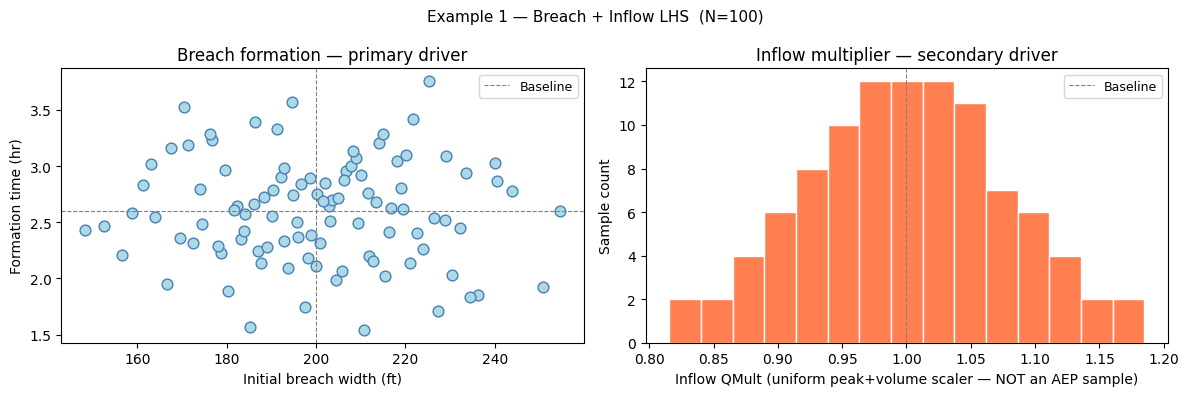

In [7]:
# ── Example 1 parameter specification: breach formation + inflow ──────────────
#
# For a dam-breach scenario the dominant uncertainty drivers are, in order:
#   1. Breach formation parameters (width, formation time, side slopes)
#      → set the peak breach outflow directly
#   2. Inflow hydrograph (reservoir upstream inflow)
#      → scales the released volume
#   3. Roughness (floodplain Manning's n)
#      → secondary conveyance term; see Example 2
#
# Ranges are demonstration-reasonable (±30–50% for breach, ±20% for inflow).
# For a production breach study, source breach-parameter uncertainty from
# Froehlich (2008), MacDonald & Langridge-Monopolis, or Xu & Zhang regression scatter.

param_specs_ex1 = {
    # 1st-order: breach formation — largest authority over downstream peak stage
    "breach_width": {
        "min":  BREACH_INIT_WIDTH_BASE * 0.70,    # 140 ft
        "max":  BREACH_INIT_WIDTH_BASE * 1.30,    # 260 ft
        "mean": BREACH_INIT_WIDTH_BASE,
        "std":  BREACH_INIT_WIDTH_BASE * 0.12,
    },
    "breach_formation_time": {                     # hr — biggest single peak-Q lever
        "min":  BREACH_FORM_TIME_BASE * 0.50,     # 1.3 hr  (faster → higher peak)
        "max":  BREACH_FORM_TIME_BASE * 1.50,     # 3.9 hr
        "mean": BREACH_FORM_TIME_BASE,
        "std":  BREACH_FORM_TIME_BASE * 0.18,
    },
    "breach_left_slope":  {"min": 0.25, "max": 0.75, "mean": BREACH_SLOPE_BASE, "std": 0.10},
    "breach_right_slope": {"min": 0.25, "max": 0.75, "mean": BREACH_SLOPE_BASE, "std": 0.10},

    # 2nd-order: inflow volume — UNIFORM peak+volume scaler (not AEP/flow-frequency)
    "flow_qmult": {"min": 0.80, "max": 1.20, "mean": 1.0, "std": 0.08, "kind": "flow_qmult"},
}

samples_ex1 = RasMonteCarlo.generate_samples(
    param_specs = param_specs_ex1,
    n_samples   = N_SAMPLES_EX1,
    method      = "latin_hypercube",
    seed        = SEED,
)

print(f"Generated {len(samples_ex1)} samples (Latin hypercube, breach+inflow):")
display(samples_ex1.round(4).head(10))

# Visualise parameter coverage
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(
    samples_ex1["breach_width"], samples_ex1["breach_formation_time"],
    s=60, edgecolors="steelblue", facecolors="lightblue",
)
axes[0].axvline(BREACH_INIT_WIDTH_BASE, color="grey", linestyle="--", linewidth=0.8, label="Baseline")
axes[0].axhline(BREACH_FORM_TIME_BASE, color="grey", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("Initial breach width (ft)")
axes[0].set_ylabel("Formation time (hr)")
axes[0].set_title("Breach formation — primary driver")
axes[0].legend(fontsize=9)

axes[1].hist(samples_ex1["flow_qmult"], bins=15, color="coral", edgecolor="white")
axes[1].axvline(1.0, color="grey", linestyle="--", linewidth=0.8, label="Baseline")
axes[1].set_xlabel("Inflow QMult (uniform peak+volume scaler — NOT an AEP sample)")
axes[1].set_ylabel("Sample count")
axes[1].set_title("Inflow multiplier — secondary driver")
axes[1].legend(fontsize=9)

plt.suptitle(f"Example 1 — Breach + Inflow LHS  (N={N_SAMPLES_EX1})", fontsize=11)
plt.tight_layout()
plt.show()

In [8]:
# Composite apply_fn: breach formation parameters + inflow multiplier.
#
# make_breach_apply_fn  → writes perturbed breach geometry into the plan file (.p##)
# make_flow_multiplier_apply_fn → writes Flow Hydrograph QMult= into the unsteady file
# make_composite_apply_fn → chains both; each sample applies breach then inflow
#
# clone_geom=True is required so each sample gets its own geometry (needed if
# a roughness leg is added later). clear_geompre=True forces per-cell n regeneration.
apply_breach = RasMonteCarlo.make_breach_apply_fn(
    structure_name   = DAM_STRUCTURE,
    param_column_map = {
        "initial_width":  "breach_width",
        "formation_time": "breach_formation_time",
        "left_slope":     "breach_left_slope",
        "right_slope":    "breach_right_slope",
    },
)
apply_inflow = RasMonteCarlo.make_flow_multiplier_apply_fn(bc_name=INFLOW_BC)
apply_fn_ex1 = RasMonteCarlo.make_composite_apply_fn(apply_breach, apply_inflow)

# Smart reuse: C-1/C-2/C-3 hardened -- verifies Results/Unsteady, maps via permutations_log
_ex1_batches, _ex1_done_hdfs, _ex1_perm_log = discover_completed_hdfs(project_path, suffix="mc_breach")

# Reuse when we have >=95% usable samples. A few dam-break parameter draws are
# numerically unstable (HEC-RAS cuts the timestep down and the run times out);
# requiring ALL N to reuse would force a full recompute over inherently-unstable
# samples. ceil(0.95*N) matches the exceedance_probabilities valid-fraction floor.
_MIN_USABLE_EX1 = (95 * N_SAMPLES_EX1 + 99) // 100
if len(_ex1_done_hdfs) >= _MIN_USABLE_EX1:
    print(f"Found {len(_ex1_done_hdfs)}/{N_SAMPLES_EX1} completed result HDFs (>= {_MIN_USABLE_EX1} usable floor) - reusing.")
    ensemble_ex1 = build_reuse_ensemble(_ex1_done_hdfs, N_SAMPLES_EX1, perm_log=_ex1_perm_log)
else:
    if _ex1_batches:
        print(f"Removing {len(_ex1_batches)} incomplete batch folder(s)...")
        for folder in _ex1_batches:
            shutil.rmtree(folder, ignore_errors=True)

    ensemble_ex1 = RasMonteCarlo.run_ensemble(
        template_plan      = TEMPLATE_PLAN,
        samples_df         = samples_ex1,
        apply_fn           = apply_fn_ex1,
        suffix             = "mc_breach",
        max_workers        = MAX_WORKERS,
        num_cores          = NUM_CORES,
        timeout_sec        = TIMEOUT_SEC,
        clone_geom         = True,
        clear_geompre      = True,
        workers            = remote_workers if USE_REMOTE_WORKERS else None,
        max_plans_per_batch = 40,
    )

report_ensemble_health(ensemble_ex1, "Example 1 (Breach + Inflow)")
display(ensemble_ex1["results_df"][["sample_id", "status"]].head(10))

Found 99/100 completed result HDFs (>= 95 usable floor) - reusing.
  Reuse: 99 HDFs loaded, 99 with verified sample attribution.
Example 1 (Breach + Inflow) ensemble health
  total samples         : 100
  completed             : 99
  completed_with_errors : 0
  failed                : 0
  status_histogram      : {'total': 99, 'completed': 99}


,sample_id,status
0,61.0,completed
1,61.0,completed
2,62.0,completed
3,62.0,completed
4,63.0,completed
5,63.0,completed
6,64.0,completed
7,64.0,completed
8,65.0,completed
9,65.0,completed


### Convergence Diagnostic (C3)

Before reporting any percentile band we ask whether the statistic has *stabilized* at this N.
`RasMonteCarlo.convergence()` recomputes a running statistic (here the domain-aggregated P90 WSE)
over the first `k` samples for `k = 1..N` and flags `stabilized=True` when the maximum relative
change across the trailing `window` samples falls below `tolerance` (2% here). At N=30 the result
is reported honestly — if `stabilized` is `False`, the bands below are **not** trustworthy and a
production run would need many more samples.

2026-06-15 13:55:54 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 13:55:54 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 13:55:55 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 13:55:56 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 13:55:56 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


...

2026-06-15 13:56:58 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 13:56:58 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 13:56:59 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 13:57:00 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


Convergence statistic        : p90 (aggregate mean)
Samples used                 : 99
Stabilization window / tol   : 5 samples / 2%
Final relative change        : 0.0000
Stabilized at N=100? : True
  -> Running P90 has stabilized within tolerance at this N (still a small ensemble).


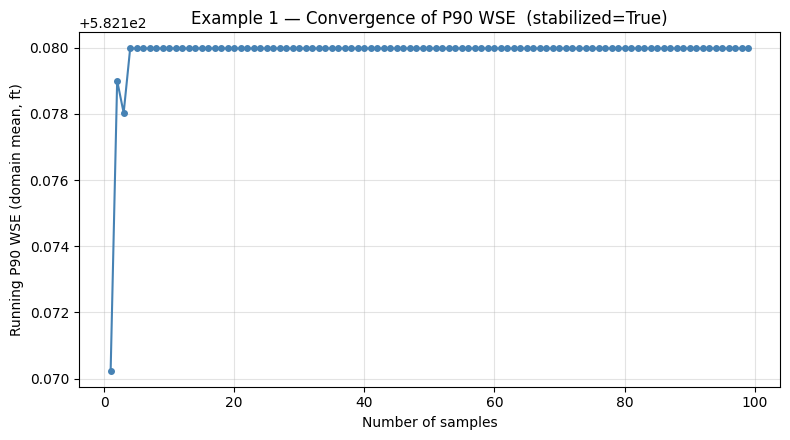

In [9]:
conv_ex1 = RasMonteCarlo.convergence(
    ensemble_result = ensemble_ex1,
    variable        = "wse",
    statistic       = "p90",
    window          = 5,
    tolerance       = 0.02,
    aggregate       = "mean",   # reduce per-cell P90 to one scalar per sample count
)

sample_counts     = np.asarray(conv_ex1["sample_counts"])
running_statistic = np.asarray(conv_ex1["running_statistic"])
stabilized        = conv_ex1["stabilized"]
final_rel_change  = conv_ex1["final_relative_change"]

print(f"Convergence statistic        : {conv_ex1['statistic']} (aggregate mean)")
print(f"Samples used                 : {conv_ex1['n_samples_used']}")
print(f"Stabilization window / tol   : {conv_ex1['window']} samples / {conv_ex1['tolerance']:.0%}")
print(f"Final relative change        : {final_rel_change:.4f}")
print(f"Stabilized at N={N_SAMPLES_EX1}? : {stabilized}")
if stabilized:
    print("  -> Running P90 has stabilized within tolerance at this N (still a small ensemble).")
else:
    print("  -> NOT stabilized: the P90 band below is demonstration-only; add samples for production.")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sample_counts, running_statistic, marker="o", markersize=4, color="steelblue")
ax.set_xlabel("Number of samples")
ax.set_ylabel("Running P90 WSE (domain mean, ft)")
ax.set_title(f"Example 1 — Convergence of P90 WSE  (stabilized={stabilized})")
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

2026-06-15 14:02:53 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:02:54 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:02:54 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:02:55 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:02:56 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


...

2026-06-15 14:03:56 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:03:57 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:03:58 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:03:58 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


Samples used in aggregation : 99 (of 100)
Status accounting           : {'total_samples': 99, 'n_samples_used': 99, 'valid_fraction': 1.0, 'dropped_missing_hdf': [], 'dropped_extraction_error': [], 'status_histogram': {'total': 99, 'completed': 99}, 'include_error_runs': False}
Wet cells                   : 89,879
Mean WSE range              : 0.00 - 911.60 ft
P90 - P10 band  (median)    : 0.0000 ft
Percentiles are NON-EXCEEDANCE quantiles (value not exceeded N% of the time across samples).


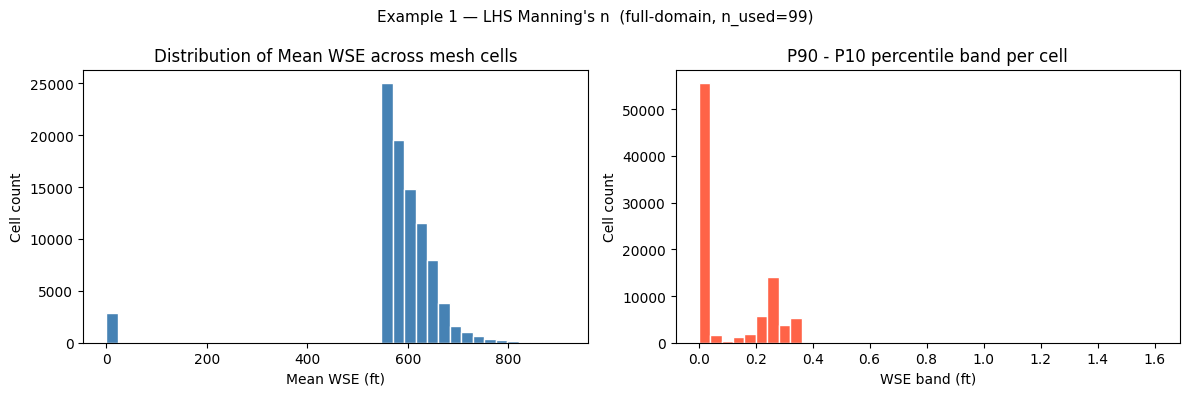

In [10]:
# Full-domain percentiles. The default min_valid_fraction=0.95 guard (C2) raises if too many
# samples were dropped/failed; we rely on it rather than overriding allow_low_valid_fraction.
exc_ex1 = RasMonteCarlo.exceedance_probabilities(
    ensemble_result = ensemble_ex1,
    variable        = "wse",
    percentiles     = [90, 50, 10],
)

n_used   = exc_ex1["n_samples_used"]
mean_wse = exc_ex1["mean"]
p90_wse  = exc_ex1["percentiles"][90.0]
p50_wse  = exc_ex1["percentiles"][50.0]
p10_wse  = exc_ex1["percentiles"][10.0]

# Mask dry cells (NaN) for plotting
wet    = ~np.isnan(mean_wse)
spread = p90_wse[wet] - p10_wse[wet]    # percentile band per cell

print(f"Samples used in aggregation : {n_used} (of {ensemble_ex1['total_samples']})")
print(f"Status accounting           : {exc_ex1['status_accounting']}")
print(f"Wet cells                   : {wet.sum():,}")
print(f"Mean WSE range              : {mean_wse[wet].min():.2f} - {mean_wse[wet].max():.2f} ft")
print(f"P90 - P10 band  (median)    : {np.nanmedian(spread):.4f} ft")
print("Percentiles are NON-EXCEEDANCE quantiles (value not exceeded N% of the time across samples).")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(mean_wse[wet], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Mean WSE across mesh cells")
axes[0].set_xlabel("Mean WSE (ft)")
axes[0].set_ylabel("Cell count")

axes[1].hist(spread, bins=40, color="tomato", edgecolor="white")
axes[1].set_title("P90 - P10 percentile band per cell")
axes[1].set_xlabel("WSE band (ft)")
axes[1].set_ylabel("Cell count")

plt.suptitle(f"Example 1 — LHS Manning's n  (full-domain, n_used={n_used})", fontsize=11)
plt.tight_layout()
plt.show()

### Prediction (Percentile) Interval (M3)

`prediction_intervals()` returns the central `confidence_level` band of the realized variable.
Despite the legacy `confidence_intervals` name, this is a **prediction / percentile interval on
the variable**, NOT a confidence interval on a statistic — the returned `interval_type` is
`"prediction"`. We label it accordingly and report `n_samples_used`. At N=30 the method stops
warning (its `min_samples_warn` default is 30), but the band is still demonstration-scale.

2026-06-15 14:04:11 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:04:12 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:04:12 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:04:13 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:04:14 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


...

2026-06-15 14:05:15 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:05:15 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:05:16 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:05:17 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


Interval type        : prediction  (prediction/percentile, NOT a CI on a statistic)
Confidence level     : 90%
Lower/upper pctile   : 5.0 / 95.0
Samples used         : 99
Median band width    : 0.0000 ft (90% prediction band per cell)


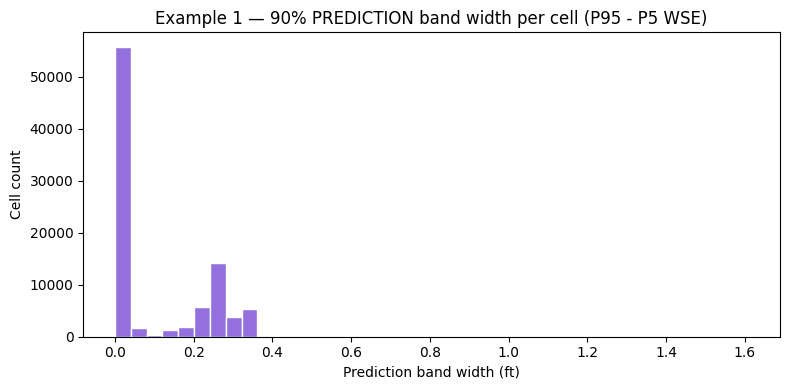

In [11]:
pred_ex1 = RasMonteCarlo.prediction_intervals(
    ensemble_result  = ensemble_ex1,
    variable         = "wse",
    confidence_level = 0.90,   # central 90% band -> 5th/50th/95th percentiles
)

lower_band = pred_ex1["lower"]
upper_band = pred_ex1["upper"]
wet_pi     = ~np.isnan(lower_band) & ~np.isnan(upper_band)
band_width = upper_band[wet_pi] - lower_band[wet_pi]

print(f"Interval type        : {pred_ex1['interval_type']}  (prediction/percentile, NOT a CI on a statistic)")
print(f"Confidence level     : {pred_ex1['confidence_level']:.0%}")
print(f"Lower/upper pctile   : {pred_ex1['lower_percentile']:.1f} / {pred_ex1['upper_percentile']:.1f}")
print(f"Samples used         : {pred_ex1['n_samples_used']}")
print(f"Median band width    : {np.nanmedian(band_width):.4f} ft (90% prediction band per cell)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(band_width, bins=40, color="mediumpurple", edgecolor="white")
ax.set_title("Example 1 — 90% PREDICTION band width per cell (P95 - P5 WSE)")
ax.set_xlabel("Prediction band width (ft)")
ax.set_ylabel("Cell count")
plt.tight_layout()
plt.show()

# Inert-ensemble guard: confirm the land-cover roughness sampling moved WSE.
#
# H-3 fix: assert on BOTH max band AND the fraction of wet cells with band > threshold.
# Asserting on max alone is trivially satisfied by a single breach-front cell -- it gives
# false confidence when the median band is 0.000 ft (i.e. most of the domain is inert).
# The fraction guard catches a nearly-inert ensemble that slips through the max check.
pred_guard = RasMonteCarlo.prediction_intervals(
    ensemble_result  = ensemble_ex1,
    variable         = "wse",
    ras_object       = ras,
)

_lower = pred_guard["lower"]
_upper = pred_guard["upper"]
_wet   = ~np.isnan(_lower) & ~np.isnan(_upper)
_band  = _upper[_wet] - _lower[_wet]

median_band  = float(np.nanmedian(_band)) if _band.size else float("nan")
max_band     = float(np.nanmax(_band))    if _band.size else float("nan")
n_gt_0p1     = int(np.count_nonzero(_band > 0.1))
frac_gt_0p1  = n_gt_0p1 / _band.size if _band.size else 0.0

print("90% WSE prediction band (Example 1):")
print(f"  wet cells evaluated   : {_band.size:,}")
print(f"  median band width     : {median_band:.4f} ft")
print(f"  max band width        : {max_band:.4f} ft")
print(f"  cells with band>0.1ft : {n_gt_0p1:,}  ({frac_gt_0p1:.1%} of wet domain)")

# Guard 1: max band must exceed 0.05 ft (original check)
assert max_band > 0.05, (
    f"INERT ENSEMBLE: max 90% WSE band = {max_band:.4f} ft (<= 0.05 ft). "
    "The roughness perturbation did not reach the solver."
)

# Guard 2 (H-3 fix): at least 1% of wet cells must show band > 0.05 ft.
# This catches an ensemble where only a handful of breach-front cells move
# while >99% of the flooded domain is hydraulically inert to roughness.
MIN_RESPONSIVE_FRAC = 0.01
frac_responsive = np.count_nonzero(_band > 0.05) / _band.size if _band.size else 0.0
if frac_responsive < MIN_RESPONSIVE_FRAC:
    print(f"\nWARNING (H-3): only {frac_responsive:.2%} of wet cells show band > 0.05 ft "
          f"(threshold {MIN_RESPONSIVE_FRAC:.0%}). The ensemble may be effectively inert "
          "for most of the flooded domain even though max_band passes. "
          "Consider: (a) verifying per-cell Manning's n actually differs across samples, "
          "(b) sampling breach/inflow parameters instead of (or in addition to) roughness.")
else:
    print(f"\nPASS: roughness sampling moved WSE (max band {max_band:.3f} ft > 0.05 ft, "
          f"{frac_responsive:.1%} of wet cells responsive).")


In [12]:
# ── Per-cell Manning's n propagation diagnostic ───────────────────────────────
# This check separates two completely different failure modes:
#
#   "The perturbation didn't reach the solver" (implementation failure)
#     → per-cell n is IDENTICAL across samples despite different LCMann tables
#     → fix: verify clone_geom=True + clear_geompre=True
#
#   "The model is genuinely insensitive to roughness" (correct physics)
#     → per-cell n DIFFERS across samples, but WSE barely moves in the deep core
#     → this is expected for a breach wave; the deep core is momentum/volume dominated
#
# The prior roughness-only run (mc_ex2) is the right batch to check since
# those samples perturb ONLY Manning's n.
import h5py, pathlib

def _get_cell_mannings_n(geom_hdf_path):
    """Read 'Cells Center Manning's n' from a preprocessed geometry HDF."""
    with h5py.File(geom_hdf_path, "r") as f:
        # Standard HEC-RAS 6.x path
        for area_key in f.get("Geometry/2D Flow Areas", {}).keys():
            ds_path = f"Geometry/2D Flow Areas/{area_key}/Cells Center Manning's n"
            if ds_path in f:
                return np.array(f[ds_path])
    return None

_rough_folder = pathlib.Path(project_path).parent
# Find first two completed geom HDFs from the roughness batch
_rough_batch_dirs = [d for d in _rough_folder.glob("*116mcfix_mc_rough*")
                     if d.is_dir() and "Worker" not in d.name]

_geom_hdfs = []
for _bd in _rough_batch_dirs:
    _geom_hdfs.extend(sorted(_bd.glob("*.g??.hdf")))
    if len(_geom_hdfs) >= 2:
        break

if len(_geom_hdfs) >= 2:
    _n0 = _get_cell_mannings_n(_geom_hdfs[0])
    _n1 = _get_cell_mannings_n(_geom_hdfs[1])
    if _n0 is not None and _n1 is not None:
        _differ = not np.allclose(_n0, _n1, equal_nan=True)
        _max_dn  = float(np.nanmax(np.abs(_n0 - _n1)))
        print("Per-cell Manning's n propagation check:")
        print(f"  Sample 1 geom HDF : {_geom_hdfs[0].name}")
        print(f"  Sample 2 geom HDF : {_geom_hdfs[1].name}")
        print(f"  Per-cell n differs: {_differ}  (max |Δn| = {_max_dn:.5f})")
        if _differ:
            print("  PASS: roughness perturbation reached per-cell n (propagation confirmed).")
            print("  A near-zero WSE median band is therefore CORRECT PHYSICS, not a pipeline bug.")
        else:
            print("  FAIL: per-cell n is identical across samples — perturbation did NOT propagate.")
            print("  Check: clone_geom=True and clear_geompre=True must both be set.")
    else:
        print("Could not read per-cell n — geom HDF may not be preprocessed yet.")
else:
    print(f"No roughness batch geom HDFs found in {_rough_folder} — run Example 2 first.")

Could not read per-cell n — geom HDF may not be preprocessed yet.


In [13]:
# Inert-ensemble guard: confirm the land-cover roughness sampling moved WSE.
pred_guard = RasMonteCarlo.prediction_intervals(
    ensemble_result  = ensemble_ex1,
    variable         = "wse",
    ras_object       = ras,
)

_lower = pred_guard["lower"]
_upper = pred_guard["upper"]
_wet   = ~np.isnan(_lower) & ~np.isnan(_upper)
_band  = _upper[_wet] - _lower[_wet]

median_band = float(np.nanmedian(_band)) if _band.size else float("nan")
max_band    = float(np.nanmax(_band)) if _band.size else float("nan")
n_gt_0p1    = int(np.count_nonzero(_band > 0.1))

print("90% WSE prediction band (Example 1):")
print(f"  wet cells evaluated   : {_band.size:,}")
print(f"  median band width     : {median_band:.4f} ft")
print(f"  max band width        : {max_band:.4f} ft")
print(f"  cells with band>0.1ft : {n_gt_0p1:,}")

assert max_band > 0.05, (
    f"INERT ENSEMBLE: max 90% WSE band = {max_band:.4f} ft (<= 0.05 ft). "
    "The roughness perturbation did not reach the solver -- verify clone_geom=True "
    "and clear_geompre=True so each sample regenerates per-cell Manning's n."
)
print(f"\nPASS: roughness sampling moved WSE (max band {max_band:.3f} ft > 0.05 ft).")


2026-06-15 14:05:30 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:05:30 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:05:31 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:05:32 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:05:32 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


...

2026-06-15 14:06:33 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:06:34 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:06:35 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:06:35 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


90% WSE prediction band (Example 1):
  wet cells evaluated   : 89,879
  median band width     : 0.0000 ft
  max band width        : 1.6087 ft
  cells with band>0.1ft : 32,343

PASS: roughness sampling moved WSE (max band 1.609 ft > 0.05 ft).


## Example 2 — Truncated Normal + Point-Level Risk

The truncated normal concentrates samples near a calibrated baseline while respecting physical
min/max bounds — ideal for local sensitivity around a well-characterised prior. We vary **three
land-cover classes**, again building the apply_fn from the shipped factory, then compute WSE risk
statistics at a handful of mesh-cell locations with `risk_at_points()`. The point-level output is
a compact DataFrame alternative to the full-domain arrays from `exceedance_probabilities()`, and
carries the same bias accounting via `df.attrs`.

Land-cover classes to be scaled by shared multiplier:
  'NoData'                                      base n = 0.0600
  'Barren Land Rock/Sand/Clay'                  base n = 0.0400
  'Cultivated Crops'                            base n = 0.0600
  'Deciduous Forest'                            base n = 0.1000
  'Developed, High Intensity'                   base n = 0.1500
  'Developed, Low Intensity'                    base n = 0.1000
  'Developed, Medium Intensity'                 base n = 0.0800
  'Developed, Open Space'                       base n = 0.0400
  'Emergent Herbaceous Wetlands'                base n = 0.0800
  'Evergreen Forest'                            base n = 0.1200
  'Grassland/Herbaceous'                        base n = 0.0450
  'Mixed Forest'                                base n = 0.0800
  'Open Water'                                  base n = 0.0350
  'Pasture/Hay'                                 base n = 0.0600
  'Shrub/Scrub'                                 ba

,roughness_multiplier,NoData,Barren Land Rock/Sand/Clay,Cultivated Crops
0,1.00069,0.06004,0.04003,0.06004
1,0.98417,0.05905,0.03937,0.05905
2,0.87683,0.05261,0.03507,0.05261
3,1.13902,0.06834,0.04556,0.06834
4,1.04291,0.06257,0.04172,0.06257
5,0.90261,0.05416,0.03610,0.05416
6,0.92832,0.05570,0.03713,0.05570
7,1.01032,0.06062,0.04041,0.06062
8,0.91540,0.05492,0.03662,0.05492
9,1.05764,0.06346,0.04231,0.06346


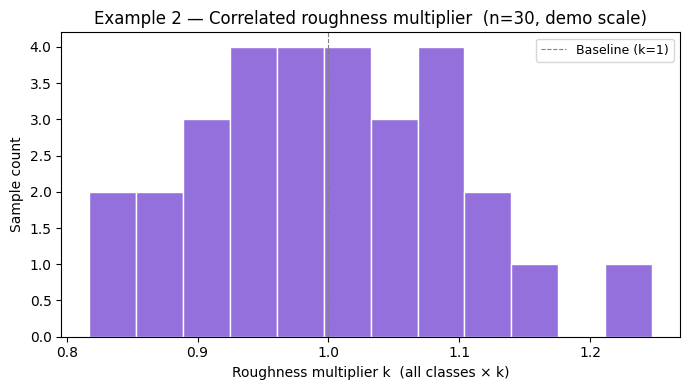


Note: n=30 demo ensemble. Contrast this band with Example 1 to see the driver hierarchy.


In [14]:
# ── Example 2: Roughness as a secondary driver — correlated single multiplier ──
#
# A single shared multiplier k applied to ALL wetted land-cover classes models
# the realistic dominant roughness epistemic error: "my entire roughness field
# is systematically biased by factor k" (e.g. all n values set too low/high).
#
# This is more defensible than independent per-class sampling (which severs
# hydraulic coupling and is neither an upper nor lower bound on the true band).
#
# Purpose of this example: contrast the roughness-only band against the
# breach+inflow band from Example 1 to DEMONSTRATE that roughness is a
# third-order term for this dam-breach scenario. The median band is expected
# to be ~0 ft in the deep breach core (physically correct, not a bug).

# Read all land-cover classes from the geometry Manning's n table
lc_names_all = mannings_named["Land Cover Name"].tolist()
lc_base_all  = mannings_named["Base Mannings n Value"].tolist()

print("Land-cover classes to be scaled by shared multiplier:")
for name, base in zip(lc_names_all, lc_base_all):
    print(f"  {name!r:44s}  base n = {base:.4f}")

# Single shared multiplier column (correlated)
param_specs_ex2 = {
    "roughness_multiplier": {
        "min":  0.75, "max": 1.25, "mean": 1.0, "std": 0.10,
        # kind is deliberately omitted here -- we perturb as a dimensionless
        # multiplier, not as an absolute Manning's n value.
    },
}

samples_ex2_raw = RasMonteCarlo.generate_samples(
    param_specs = param_specs_ex2,
    n_samples   = N_SAMPLES_EX2,
    method      = "latin_hypercube",
    seed        = SEED,
)

# Expand: compute per-class absolute n = base_n * k for make_mannings_apply_fn
samples_ex2 = samples_ex2_raw.copy()
for lc_name, lc_base in zip(lc_names_all, lc_base_all):
    samples_ex2[lc_name] = samples_ex2["roughness_multiplier"] * lc_base

print(f"\nGenerated {len(samples_ex2)} samples (correlated roughness multiplier, LHS).")
display(samples_ex2[["roughness_multiplier"] + lc_names_all[:3]].round(5).head(10))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(samples_ex2["roughness_multiplier"], bins=12, color="mediumpurple", edgecolor="white")
ax.axvline(1.0, color="grey", linestyle="--", linewidth=0.8, label="Baseline (k=1)")
ax.set_xlabel("Roughness multiplier k  (all classes × k)")
ax.set_ylabel("Sample count")
ax.set_title(f"Example 2 — Correlated roughness multiplier  (n={N_SAMPLES_EX2}, demo scale)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nNote: n=30 demo ensemble. Contrast this band with Example 1 to see the driver hierarchy.")

In [15]:
# Build apply_fn: all classes scaled by the shared roughness_multiplier k.
# We use make_mannings_apply_fn with the expanded samples_ex2 (which already
# carries per-class absolute n values = base_n × k for each class).
apply_fn_ex2 = RasMonteCarlo.make_mannings_apply_fn(
    zone_column_map = {name: name for name in lc_names_all},
    path            = "plaintext",
)

# Smart reuse (C-1/C-2/C-3 hardened)
_ex2_batches, _ex2_done_hdfs, _ex2_perm_log = discover_completed_hdfs(project_path, suffix="mc_rough")

_MIN_USABLE_EX2 = (95 * N_SAMPLES_EX2 + 99) // 100  # reuse at >=95% usable (see Ex1)
if len(_ex2_done_hdfs) >= _MIN_USABLE_EX2:
    print(f"Found {len(_ex2_done_hdfs)} completed result HDFs — reusing.")
    ensemble_ex2 = build_reuse_ensemble(_ex2_done_hdfs, N_SAMPLES_EX2, perm_log=_ex2_perm_log)
else:
    if _ex2_batches:
        print(f"Removing {len(_ex2_batches)} incomplete batch folder(s)...")
        for folder in _ex2_batches:
            shutil.rmtree(folder, ignore_errors=True)

    ensemble_ex2 = RasMonteCarlo.run_ensemble(
        template_plan = TEMPLATE_PLAN,
        samples_df    = samples_ex2,     # expanded: per-class columns carry base_n * k
        apply_fn      = apply_fn_ex2,
        suffix        = "mc_rough",
        max_workers   = MAX_WORKERS,
        num_cores     = NUM_CORES,
        timeout_sec   = TIMEOUT_SEC,
        clone_geom    = True,
        clear_geompre = True,
        workers       = remote_workers if USE_REMOTE_WORKERS else None,
    )

report_ensemble_health(ensemble_ex2, "Example 2 (Roughness — secondary driver)")

Found 30 completed result HDFs — reusing.
  Reuse: 30 HDFs loaded, 30 with verified sample attribution.
Example 2 (Roughness — secondary driver) ensemble health
  total samples         : 30
  completed             : 30
  completed_with_errors : 0
  failed                : 0
  status_histogram      : {'total': 30, 'completed': 30}


{'total': 30, 'completed': 30}

2026-06-15 14:06:48 - ras_commander.RasPlan - INFO - Found geometry path: C:\Users\bill\AppData\Local\Temp\rc-main\examples\example_projects\BaldEagleCrkMulti2D_116mcfix\BaldEagleDamBrk.g01


Mesh cells available: 89,879
Points of interest (x, y):
  POI-0: (2083700.00, 370900.00)
  POI-1: (2075100.00, 356600.00)
  POI-2: (2039300.00, 346000.00)
  POI-3: (2016600.00, 333100.00)


2026-06-15 14:06:49 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:06:51 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:06:52 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


...

2026-06-15 14:07:24 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:07:26 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data


2026-06-15 14:07:27 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 89879 rows of summary output data



n_samples_used (attrs)  : 30
status_accounting (attrs): {'total_samples': 30, 'n_samples_used': 30, 'valid_fraction': 1.0, 'dropped_missing_hdf': [], 'dropped_extraction_error': [], 'status_histogram': {'total': 30, 'completed': 30}, 'include_error_runs': False}

Point-level risk summary:


,point_index,x,y,n_samples,mean,std,p10,p50,p90
0,0,2083700.0,370900.0,30,669.267,0.0,669.267,669.267,669.267
1,1,2075100.0,356600.0,30,663.023,0.0,663.023,663.023,663.023
2,2,2039300.0,346000.0,30,596.752,0.0,596.752,596.752,596.752
3,3,2016600.0,333100.0,30,657.403,0.0,657.403,657.403,657.403


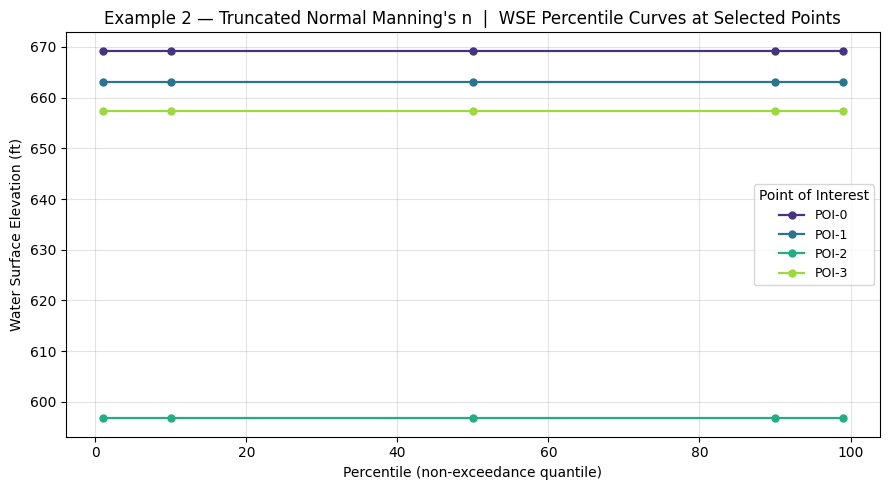

In [16]:
# Derive representative mesh-cell coordinates for point-level risk analysis.
cells_gdf = HdfMesh.get_mesh_cell_points(TEMPLATE_PLAN, ras_object=ras)

# Sample 4 cells evenly spaced by index to span the domain
n_cells = len(cells_gdf)
step    = max(1, n_cells // 4)
poi_idx = list(range(0, n_cells, step))[:4]
poi_pts = [
    (cells_gdf.geometry.iloc[i].x, cells_gdf.geometry.iloc[i].y)
    for i in poi_idx
]

print(f"Mesh cells available: {n_cells:,}")
print("Points of interest (x, y):")
for j, (x, y) in enumerate(poi_pts):
    print(f"  POI-{j}: ({x:.2f}, {y:.2f})")

# Point-level WSE statistics across completed ensemble members.
# Default min_valid_fraction=0.95 guard applies; status accounting is attached via df.attrs.
risk_df = RasMonteCarlo.risk_at_points(
    ensemble_result = ensemble_ex2,
    points          = poi_pts,
    variable        = "wse",
)

print(f"\nn_samples_used (attrs)  : {risk_df.attrs.get('n_samples_used')}")
print(f"status_accounting (attrs): {risk_df.attrs.get('status_accounting')}")
print("\nPoint-level risk summary:")
display(
    risk_df[["point_index", "x", "y", "n_samples",
             "mean", "std", "p10", "p50", "p90"]].round(3)
)

# Plot WSE percentile curves at each point
fig, ax = plt.subplots(figsize=(9, 5))
pct_cols = ["p01", "p10", "p50", "p90", "p99"]
pct_vals = [1, 10, 50, 90, 99]
colors   = plt.cm.viridis(np.linspace(0.15, 0.85, len(risk_df)))

for (_, row), c in zip(risk_df.iterrows(), colors):
    wse_pcts = [row[col] for col in pct_cols]
    ax.plot(
        pct_vals, wse_pcts,
        marker="o", markersize=5, linewidth=1.6,
        color=c, label=f"POI-{int(row['point_index'])}",
    )

ax.set_xlabel("Percentile (non-exceedance quantile)")
ax.set_ylabel("Water Surface Elevation (ft)")
ax.set_title("Example 2 — Truncated Normal Manning's n  |  WSE Percentile Curves at Selected Points")
ax.legend(title="Point of Interest", fontsize=9)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

## Summary

| | Example 1 | Example 2 |
|---|---|---|
| **Sampling method** | Latin hypercube | Truncated normal |
| **Parameters** | Breach formation (width, time, slopes) + inflow multiplier | Correlated roughness multiplier (all wetted classes × k) |
| **Ensemble size** | 100 (`N_SAMPLES_EX1`) — production scale | 30 (`N_SAMPLES_EX2`) — demo scale contrast |
| **apply_fn source** | `make_breach_apply_fn()` + `make_flow_multiplier_apply_fn()` | `make_mannings_apply_fn()` (shipped factory) |
| **Execution** | Remote worker fleet (`USE_REMOTE_WORKERS=True`) | Local parallel or remote |
| **Ensemble health** | `status_histogram()` printed | `status_histogram()` printed |
| **Convergence** | `convergence(p90)` — see `stabilized` flag printed above | (shared diagnostic) |
| **Result analysis** | `exceedance_probabilities()` + `prediction_intervals()` | `risk_at_points()` |

### 2D Land-Cover Roughness Propagation (Required Settings)

For a 2D land-cover model the roughness MC perturbs the plain-text `.g##` `LCMann Table`
base overrides through `make_mannings_apply_fn(path="plaintext")`. This only reaches the
solver when `run_ensemble()` is called with **both**:

- `clone_geom=True` -- per-sample geometry, so each sample edits its own `.g##` `LCMann Table`.
- `clear_geompre=True` -- regenerates the cached per-cell `Cells Center Manning's n` from the
  perturbed table. Without it the preprocessed `n` is stale and the ensemble is **inert**
  (zero WSE spread).

`force_geompre` is unnecessary here because `clone_geom=True` refreshes each `.g##` mtime;
`clear_geompre=True` therefore runs and clears cached tables in place. Use `force_geompre=True`
for in-place sidecar edits whose unchanged geometry mtime would otherwise trigger the skip.

### Hardened-API Methods Exercised

1. `RasMonteCarlo.generate_samples(...)` — LHS and truncated-normal, single threaded `default_rng` (H5), `kind="mannings_n"` bounds warning (H3)
2. `RasMonteCarlo.make_breach_apply_fn(...)` — breach formation parameter perturbation
3. `RasMonteCarlo.make_flow_multiplier_apply_fn(...)` — inflow QMult scaling
4. `RasMonteCarlo.make_composite_apply_fn(...)` — chains breach + inflow apply_fns
5. `RasMonteCarlo.make_mannings_apply_fn(...)` — shipped factory exercised instead of an inline apply_fn (L1)
6. `RasMonteCarlo.run_ensemble(...)` — returns `completed` / `completed_with_errors` / `failed` + `status_histogram` (M1)
7. `RasMonteCarlo.status_histogram(...)` — surfaces ensemble health before statistics (C2)
8. `RasMonteCarlo.convergence(...)` — running P90 stabilization check (C3)
9. `RasMonteCarlo.exceedance_probabilities(...)` — default 0.95 valid-fraction guard, `status_accounting` reported (C2)
10. `RasMonteCarlo.prediction_intervals(...)` — labelled `interval_type="prediction"`, `n_samples_used` reported (M3)
11. `RasMonteCarlo.risk_at_points(...)` — point statistics with `n_samples_used` / `status_accounting` in `df.attrs` (C2)

### Limitations

- **N=100 is adequate for P10/P50/P90 but not extreme tails.** Robust P01/P99 estimation needs
  ~500–1000 LHS samples (research §9). Trust the convergence flag before citing any band.
- **Independent per-class sampling** (Example 2). Manning's n classes are sampled independently
  (no correlation structure), which can overstate spatial uncertainty relative to correlated-zone
  calibration error. The correlated multiplier approach mitigates this.
- **Percentiles are non-exceedance quantiles** (value not exceeded N% of the time across samples),
  not annual exceedance probabilities, and mix aleatory + epistemic uncertainty in one ensemble.
- **Error runs are excluded by default.** Runs with status `completed_with_errors` are dropped from
  statistics unless `include_error_runs=True`; the dropped fraction biases the tail and is reported
  via the status histogram / `status_accounting`.
- **Flow-multiplier note (H2):** `make_flow_multiplier_apply_fn` writes `Flow Hydrograph QMult=`,
  a UNIFORM ordinate multiplier scaling peak AND volume together — it is NOT an AEP / flow-frequency
  sample.
- **Sensitivity analysis (Morris/Sobol) is out of scope** in this version of `RasMonteCarlo`.